In [ ]:
import torch

from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from torchvision import transforms
from torchvision.utils import make_grid

import numpy as np
import matplotlib.pyplot as plt


from robustbench.utils import load_model
from src.data.filtering import get_correct_indices, save_indices

c:\Users\balaj\miniconda3\Lib\site-packages\robustbench\loaders.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [ ]:
batch_size = 4
transform = transforms.Compose([transforms.ToTensor()])
testset = CIFAR10(root='./data', train=False, download=True, transform=transform)

c:\Users\balaj\miniconda3\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

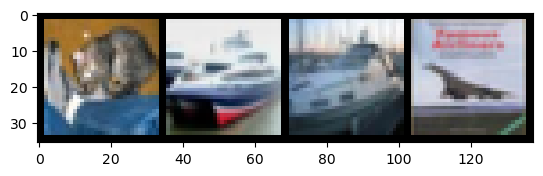

cat   ship  ship  plane


In [5]:

testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
dataiter = iter(testloader)
images, labels = next(dataiter)

imshow(make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [6]:
surrogate_1 = load_model(model_name='Standard', dataset='cifar10', threat_model='Linf').to(device).eval()

In [7]:
indices = get_correct_indices(
    model=surrogate_1,
    dataset=testset,
    device=device,
    batch_size=batch_size,
)

Filtering correct samples: 100%|██████████| 2500/2500 [01:28<00:00, 28.41it/s]


In [9]:
save_indices(indices, save_path="./data/cifar10_correct_indices.json")

Saved 9478 indices to ./data/cifar10_correct_indices.json
